## KPI metrics 
### KPI 1: Pricing Drivers Analysis
Looking into possible conditions which play into the KPI for Listing Prices 
- Neighbourhood
- Reviews of Listing
- Type of Property that is listed
- Availability for the property throughout the Year

In [266]:
pip install pandas numpy matplotlib seaborn 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [267]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [268]:
df= pd.read_csv('Cleaned_Airbnb_Dataset.csv')
df.head()
df.iloc[1]

/var/folders/39/pt6v5j6d1sl0_v9jrw837wjr0000gp/T/ipykernel_24241/1007344700.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('Cleaned_Airbnb_Dataset.csv')


Unnamed: 0                                                                        1
id                                                                          1002102
NAME                                                          Skylit Midtown Castle
host id                                                                 52335172823
host_identity_verified                                                     verified
host name                                                                     Jenna
neighbourhood group                                                       Manhattan
neighbourhood                                                               Midtown
lat                                                                        40.75362
long                                                                      -73.98377
instant_bookable                                                              False
cancellation_policy                                                        m

In [269]:
#checking average price of properties in different neighbourhoods and neighbourhood groups based on the dataset
average_price_neighbourhood_group = (df.groupby('neighbourhood group')['price'].mean())
print(average_price_neighbourhood_group)

neighbourhood group
Bronx            630.461233
Brooklyn         626.720555
Manhattan        622.878966
Queens           629.717162
Staten Island    622.883825
Name: price, dtype: float64


#### Average Price by NeighbourHood and Neighbourhood Group

In [270]:
#finding out the average listing prices of areas and neighbourhoods and all the price rantes and the number of listings in the area with a small filter having a minimum of 10 properties in the region 
average_price_neighbourhood = (
    df.groupby('neighbourhood').agg(
        average_price = ('price' , 'mean'),
        listings = ('id' , 'count') ,
        max_price = ('price' , 'max') ,
        min_price = ('price' , 'min')
    )
    .sort_values(['neighbourhood' , 'average_price' ] , ascending = True)
)
average_price_neighbourhood = average_price_neighbourhood[average_price_neighbourhood['listings'] > 10]
print(average_price_neighbourhood)


                 average_price  listings  max_price  min_price
neighbourhood                                                 
Allerton            648.736907        94     1195.0       52.0
Arrochar            622.091538        50     1196.0      116.0
Arverne             647.603687       217     1196.0       86.0
Astoria             638.372571      1835     1200.0       50.0
Bath Beach          723.148936        47     1152.0      105.0
...                        ...       ...        ...        ...
Williamsburg        625.598643      7641     1200.0       50.0
Windsor Terrace     577.994180       328     1194.0       51.0
Woodhaven           625.592607       190     1199.0       51.0
Woodlawn            587.137931        29     1121.0      120.0
Woodside            636.609440       582     1200.0       51.0

[195 rows x 4 columns]


In [271]:
average_price_neighbourhood_group = (
    df.groupby('neighbourhood group').agg(
        average_price = ('price' , 'mean'),
        listings = ('id' , 'count') ,
        max_price = ('price' , 'max') ,
        min_price = ('price' , 'min')
    )
    .sort_values(['neighbourhood group' , 'average_price' ] , ascending = True)
)
average_price_neighbourhood_group = average_price_neighbourhood_group[average_price_neighbourhood_group['listings'] > 10]
print(average_price_neighbourhood_group)

                     average_price  listings  max_price  min_price
neighbourhood group                                               
Bronx                   630.461233      2653     1200.0       50.0
Brooklyn                626.720555     41177     1200.0       50.0
Manhattan               622.878966     43054     1200.0       50.0
Queens                  629.717162     13055     1200.0       50.0
Staten Island           622.883825       938     1200.0       50.0


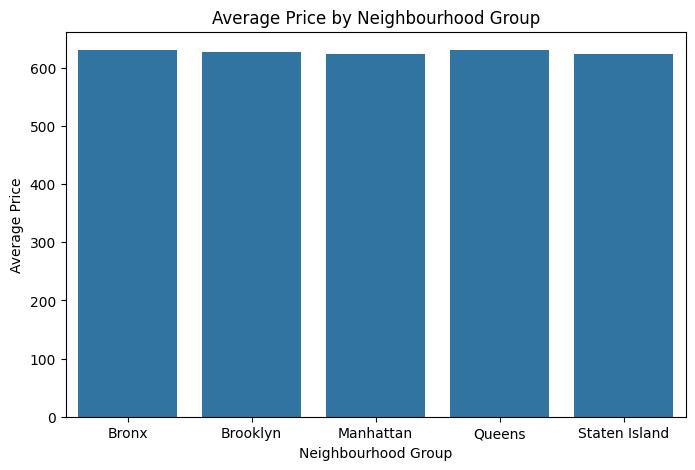

In [272]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=average_price_neighbourhood_group.reset_index(),
    x='neighbourhood group',
    y='average_price'
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

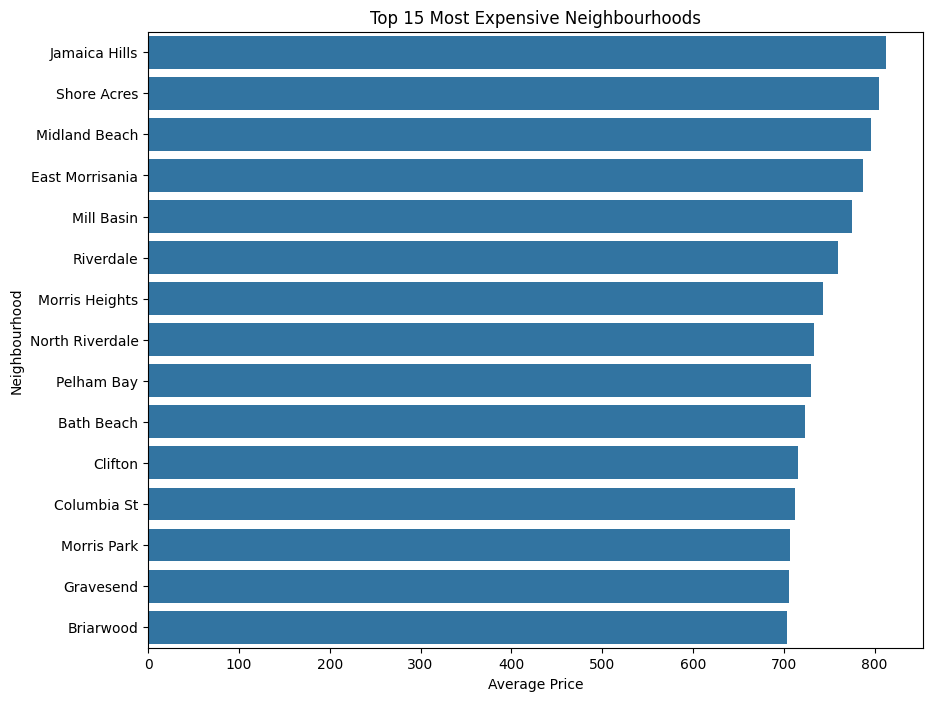

In [273]:
top_15 = (
    average_price_neighbourhood
    .sort_values(
        'average_price',
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_15.reset_index(),
    y='neighbourhood',
    x='average_price'
)

plt.title("Top 15 Most Expensive Neighbourhoods")
plt.xlabel("Average Price")
plt.ylabel("Neighbourhood")
plt.show()

##### Average Price based on the average price and its ratings in neighbourhood and neighbourhood groups 

In [274]:
# Handling Reviews based on listings and areas to see which area has the most profitable listings
average_listing_reviews_by_neighbourhood_group = (
    df.groupby('neighbourhood group').agg(
        reviews = ('review rate number' , 'mean' ) ,
        listings = ('id' , 'count') ,
        min_rating = ('review rate number' , 'min') ,
        max_rating = ('review rate number' , 'max') , 
        price = ('price' , 'mean')
    )
    .sort_values(by = 'neighbourhood group' ,
                 ascending = True) 
)
print(average_listing_reviews_by_neighbourhood_group)

                      reviews  listings  min_rating  max_rating       price
neighbourhood group                                                        
Bronx                3.332579      2653         1.0         5.0  630.461233
Brooklyn             3.258959     41177         1.0         5.0  626.720555
Manhattan            3.276816     43054         1.0         5.0  622.878966
Queens               3.329451     13055         1.0         5.0  629.717162
Staten Island        3.405983       938         1.0         5.0  622.883825


In [275]:
# Handling Reviews based on listings and areas to see which area has the most profitable listings
average_listing_reviews_by_neighbourhood = (
    df.groupby('neighbourhood').agg(
        reviews = ('review rate number' , 'mean' ) ,
        listings = ('id' , 'count') ,
        price = ('price' , 'mean')
    )
    .sort_values(by = 'neighbourhood' ,
                 ascending = True) 
)
print(average_listing_reviews_by_neighbourhood)

                  reviews  listings       price
neighbourhood                                  
Allerton         3.319149        94  648.736907
Arden Heights    3.777778         9  804.888889
Arrochar         3.480000        50  622.091538
Arverne          3.239631       217  647.603687
Astoria          3.224523      1835  638.372571
...                   ...       ...         ...
Windsor Terrace  3.097561       328  577.994180
Woodhaven        3.326316       190  625.592607
Woodlawn         3.310345        29  587.137931
Woodrow          4.000000         3  709.333333
Woodside         3.408935       582  636.609440

[224 rows x 3 columns]


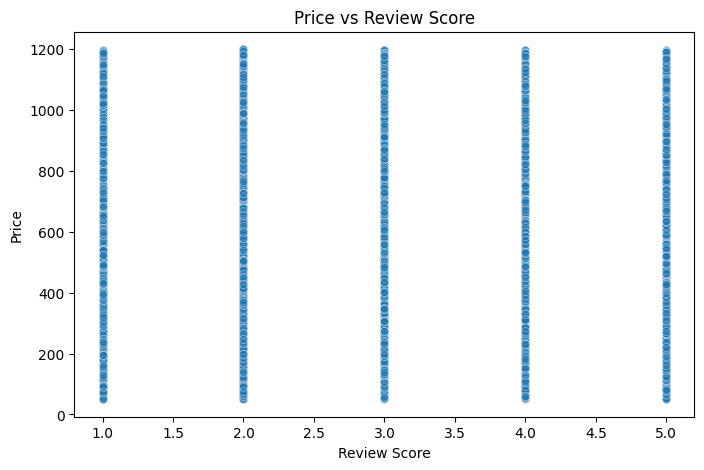

In [276]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x='review rate number',
    y='price',
    alpha=0.5
)

plt.title("Price vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Price")
plt.show()

##### Average Price by Room Type 

In [277]:
#checking the overall ditributiuon of the room type for overall dataset 
room_type_price = (
    df.groupby('room type').agg(
        room_type_count = ('id' , 'count') ,
        room_type_price_avg = ('price' , 'mean') , 
        room_median_price = ('price' , 'median')

    )
)
print(room_type_price)
# in general hotels seem to be charging the most though there are lesser hotel type listings

                 room_type_count  room_type_price_avg  room_median_price
room type                                                               
Entire home/apt            52826           625.475959         625.000000
Hotel room                   115           666.391304         643.000000
Private room               45755           625.130601         624.000000
Shared room                 2181           633.131988         649.589744


In [278]:
#performing a price vs roomtype value analysis for ratings to see what is the most popular type of roomtype in each neighbourhood group and neighbourhood
price_roomtype = (
    df.groupby(['neighbourhood group' , 'room type']).agg(
        price = ('price' ,'mean')  ,
        price_median = ('price' , 'median') ,
        listings = ('id' , 'count')  
        
    )
    .sort_values(by ='neighbourhood group' , ascending = True)
)
price_roomtype  = price_roomtype[price_roomtype['listings'] >= 100]
print(price_roomtype)

#the market is dominated by entire home/apt or private rooms 

                                          price  price_median  listings
neighbourhood group room type                                          
Bronx               Entire home/apt  623.248745         618.5      1004
                    Private room     637.481062         656.0      1536
                    Shared room      599.123894         608.0       113
Brooklyn            Entire home/apt  627.425387         626.0     20252
                    Private room     625.788418         625.0     20105
                    Shared room      631.482423         659.0       813
Manhattan           Shared room      634.631666         645.5       886
                    Private room     620.820807         620.0     16037
                    Hotel room       681.870000         644.5       100
                    Entire home/apt  623.520305         624.0     26031
Queens              Entire home/apt  626.624540         625.0      5072
                    Private room     631.479450         629.0   

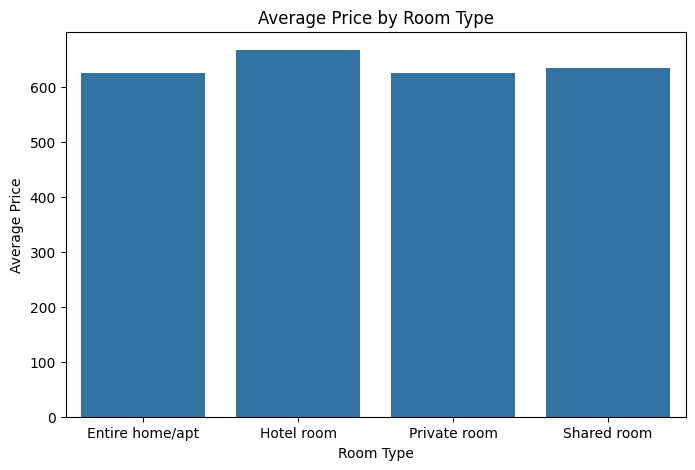

In [279]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=room_type_price.reset_index(),
    x='room type',
    y='room_type_price_avg'
)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()

#### Price VS Availability Comparison 

In [280]:
#now checking based on availability 
room_type_availablity = (
    df.groupby('room type').agg(
        avg_availability = ('availability 365' , 'mean') , 
        price_mean = ('price' , 'mean') , 
        listings = ('id' , 'count')
    )
)
print(room_type_availablity)
#seeing some correlation here where greater the avg availability , more the avg price for the room type

                 avg_availability  price_mean  listings
room type                                              
Entire home/apt        143.287302  625.475959     52826
Hotel room             219.930435  666.391304       115
Private room           137.852497  625.130601     45755
Shared room            173.563961  633.131988      2181


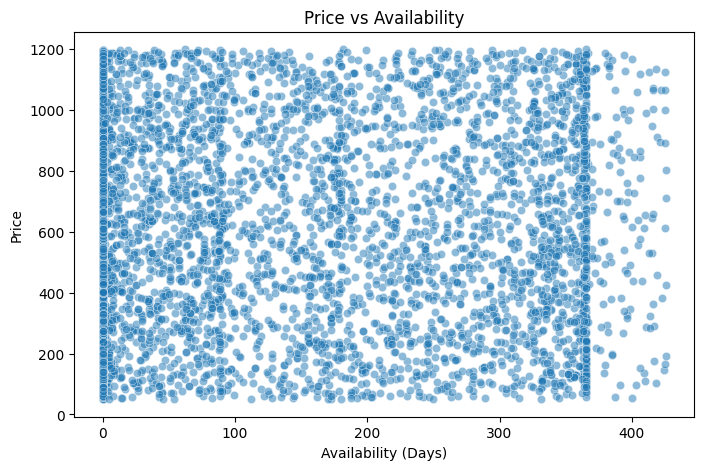

In [281]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x='availability 365',
    y='price',
    alpha=0.5
)

plt.title("Price vs Availability")
plt.xlabel("Availability (Days)")
plt.ylabel("Price")
plt.show()

### KPI 2: Neighborhood Market Analysis

#### Business Question
Which neighborhoods represent the strongest Airbnb markets?

#### Metrics
- Number of Listings
- Average Price
- Average Review Score
- Reviews Per Month
- Availability

#### Expected Outcome
Identify premium markets, high-demand areas, and potential market opportunities.

In [282]:
neighbourhood_listings = df.groupby('neighbourhood').agg(
    listings = ('id' , 'count') ,

)
neighbourhood_listings = neighbourhood_listings[neighbourhood_listings['listings'] >=10]
print(neighbourhood_listings)

                 listings
neighbourhood            
Allerton               94
Arrochar               50
Arverne               217
Astoria              1835
Bath Beach             47
...                   ...
Williamsburg         7641
Windsor Terrace       328
Woodhaven             190
Woodlawn               29
Woodside              582

[197 rows x 1 columns]


In [283]:
neighbourhood_group_listings = df.groupby('neighbourhood group').agg(
    listings = ('id' , 'count') ,

)
neighbourhood_group_listings = neighbourhood_group_listings[neighbourhood_group_listings['listings'] >=10]
print(neighbourhood_group_listings)

                     listings
neighbourhood group          
Bronx                    2653
Brooklyn                41177
Manhattan               43054
Queens                  13055
Staten Island             938


<Axes: xlabel='listings', ylabel='neighbourhood'>

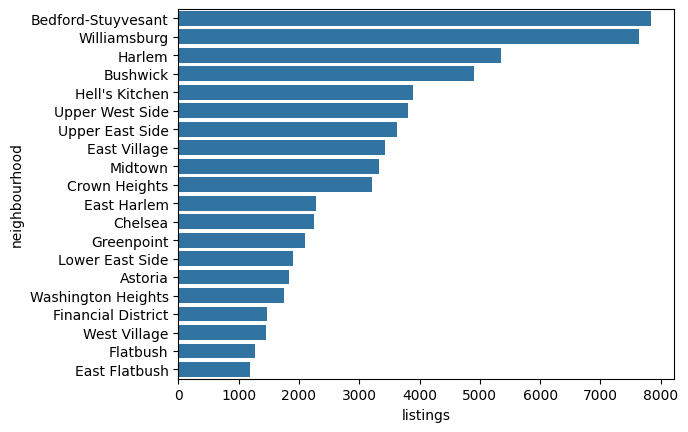

In [284]:
top_20 = (
    neighbourhood_listings
    .sort_values(
        'listings',
        ascending=False
    )
    .head(20)
)

sns.barplot(
    data=top_20.reset_index(),
    y='neighbourhood',
    x='listings'
)

##### Average Price based on the Neighbourhood

In [285]:
neighbourhood_group_price = df.groupby('neighbourhood group').agg(
    listings = ('id' , 'count') ,
    mean_price = ('price' ,'mean') ,
    median_price  = ('price' , 'median') ,
    price_std = ('price' , 'std')

)
print(neighbourhood_group_price)

                     listings  mean_price  median_price   price_std
neighbourhood group                                                
Bronx                    2653  630.461233    642.000000  323.087108
Brooklyn                41177  626.720555    626.648931  331.627654
Manhattan               43054  622.878966    622.000000  330.838593
Queens                  13055  629.717162    628.000000  333.804337
Staten Island             938  622.883825    626.000000  325.668739


In [286]:
neighbourhood_price = df.groupby('neighbourhood').agg(
    listings = ('id' , 'count') ,
    mean_price = ('price' , 'mean') ,
    median_price = ('price' , 'median') ,
    price_std = ('price' , 'std')
).sort_values(by = 'listings', ascending= False)
print(neighbourhood_price.head(10))

                    listings  mean_price  median_price   price_std
neighbourhood                                                     
Bedford-Stuyvesant      7832  623.251004    622.000000  330.057583
Williamsburg            7641  625.598643    627.000000  330.657368
Harlem                  5357  627.752833    622.000000  330.035997
Bushwick                4910  633.357831    639.230273  335.978431
Hell's Kitchen          3898  620.770219    619.500000  331.754779
Upper West Side         3808  616.734574    619.000000  327.685842
Upper East Side         3628  619.731917    627.000000  333.090159
East Village            3424  618.579572    617.000000  334.843157
Midtown                 3335  609.734695    609.000000  324.035641
Crown Heights           3219  617.750216    619.000000  328.813636


<Axes: xlabel='neighbourhood group', ylabel='median_price'>

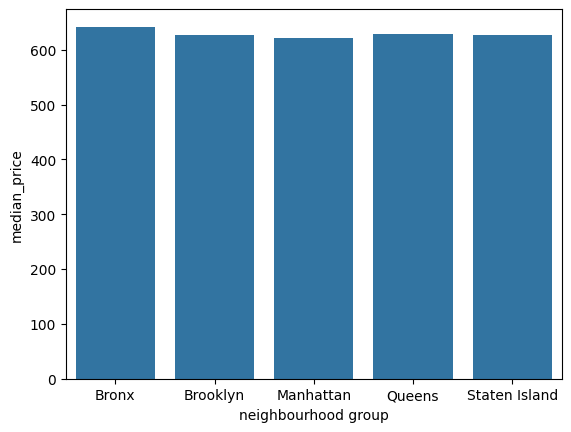

In [287]:
sns.barplot(
    data=neighbourhood_group_price.reset_index(),
    x='neighbourhood group',
    y='median_price'
)

##### Reviews in the Neighbourhood 


In [288]:
neighbourhood_group_reviews = df.groupby(
    'neighbourhood group'
).agg(
    avg_reviews_rating = ('review rate number' , 'mean') , 
    listings = ('id' , 'count') ,
    reviews_per_month = ('reviews per month' , 'mean')

).sort_values(by = ['avg_reviews_rating' , 'listings'], ascending=False)
print(neighbourhood_group_reviews)

                     avg_reviews_rating  listings  reviews_per_month
neighbourhood group                                                 
Staten Island                  3.405983       938           1.722608
Bronx                          3.332579      2653           1.742803
Queens                         3.329451     13055           1.826437
Manhattan                      3.276816     43054           1.264940
Brooklyn                       3.258959     41177           1.310030


In [289]:
neighbourhood_reviews = df.groupby(
    'neighbourhood'
).agg(
    avg_reviews_rating = ('review rate number' , 'mean') , 
    listings = ('id' , 'count') ,
    reviews_per_month = ('reviews per month' , 'mean')

).sort_values(by = ['avg_reviews_rating' , 'listings'], ascending=False)
print(neighbourhood_reviews.head(20))

                 avg_reviews_rating  listings  reviews_per_month
neighbourhood                                                   
Glen Oaks                  4.500000         2           3.980000
Co-op City                 4.400000         5           0.424000
Gerritsen Beach            4.333333         3           3.290000
Huguenot                   4.111111         9           3.674444
Silver Lake                4.000000         9           3.453333
Eltingville                4.000000         7           2.410000
Todt Hill                  4.000000         6           0.993333
West Farms                 4.000000         6           0.781667
Woodrow                    4.000000         3           3.660000
Rosebank                   3.928571        14           3.078571
Bull's Head                3.916667        12           2.036667
Grymes Hill                3.882353        17           1.865625
Little Neck                3.875000         8           0.331667
Oakwood                  

<Axes: xlabel='avg_reviews_rating', ylabel='neighbourhood'>

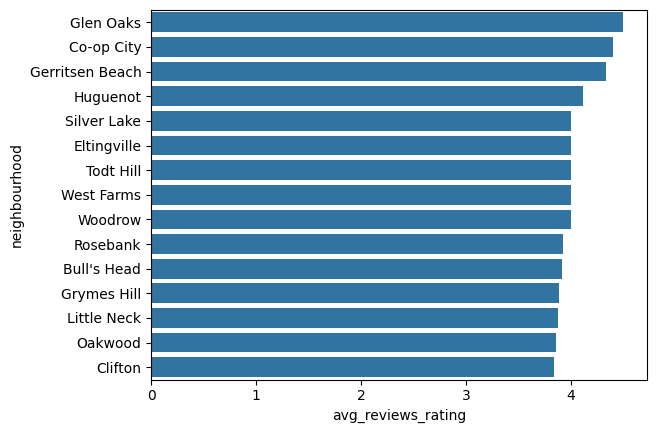

In [290]:
top_reviews = (
    neighbourhood_reviews
    .head(15)
)

sns.barplot(
    data=top_reviews.reset_index(),
    y='neighbourhood',
    x='avg_reviews_rating'
)

##### Last reviews

In [291]:
neighbourhood_last_reviews = df.groupby(
    'neighbourhood'
).agg(
    avg_reviews_rating = ('review rate number' , 'mean') , 
    listings = ('id' , 'count') ,
    reviews_per_month = ('reviews per month' , 'mean')

).sort_values(by = 'reviews_per_month' , ascending=False)
print(neighbourhood_last_reviews.head(20))

                        avg_reviews_rating  listings  reviews_per_month
neighbourhood                                                          
East Elmhurst                     3.362683       477           4.296858
Glen Oaks                         4.500000         2           3.980000
Springfield Gardens               3.365854       246           3.702447
Huguenot                          4.111111         9           3.674444
Woodrow                           4.000000         3           3.660000
New Dorp Beach                    3.545455        11           3.645000
Silver Lake                       4.000000         9           3.453333
Castle Hill                       2.812500        16           3.318750
Gerritsen Beach                   4.333333         3           3.290000
Chelsea, Staten Island            2.000000         1           3.100000
Rosebank                          3.928571        14           3.078571
Whitestone                        3.000000        26           3

In [292]:
neighbourhood_groups_last_reviews = df.groupby(
    'neighbourhood group'
).agg(
    avg_reviews_rating = ('review rate number' , 'mean') , 
    listings = ('id' , 'count') ,
    reviews_per_month = ('reviews per month' , 'mean')

).sort_values(by = 'reviews_per_month' , ascending=False)
print(neighbourhood_groups_last_reviews.head(20))

                     avg_reviews_rating  listings  reviews_per_month
neighbourhood group                                                 
Queens                         3.329451     13055           1.826437
Bronx                          3.332579      2653           1.742803
Staten Island                  3.405983       938           1.722608
Brooklyn                       3.258959     41177           1.310030
Manhattan                      3.276816     43054           1.264940


<Axes: xlabel='reviews_per_month', ylabel='neighbourhood'>

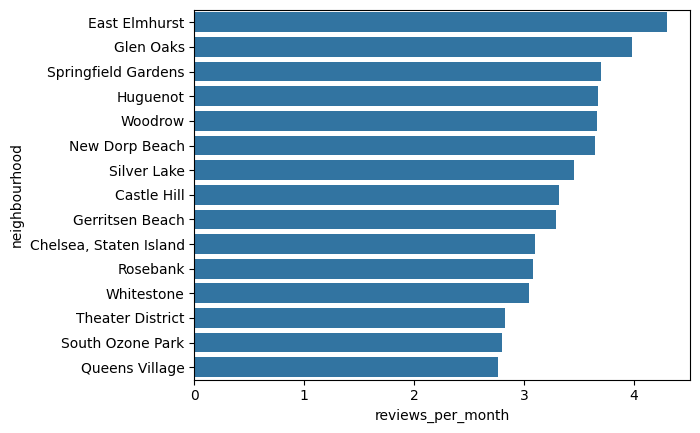

In [293]:
top_demand = (
    neighbourhood_last_reviews
    .head(15)
)

sns.barplot(
    data=top_demand.reset_index(),
    y='neighbourhood',
    x='reviews_per_month'
)

##### Availability for the Neighbourhoods


In [294]:
neighbourhood_last_reviews = df.groupby(
    'neighbourhood'
).agg(
    listings = ('id' , 'count') ,
    availability = ('availability 365' , 'mean')

).sort_values(by = 'availability' , ascending=True)
print(neighbourhood_last_reviews.head(20))

                            listings  availability
neighbourhood                                     
Bay Terrace, Staten Island         4      0.000000
New Dorp                           4     22.750000
Navy Yard                         30     68.700000
Todt Hill                          6     70.333333
Stuyvesant Town                   81     79.370370
Downtown Brooklyn                174     82.229885
Woodlawn                          29     87.103448
Emerson Hill                      10     87.200000
Morningside Heights              621     88.112721
Civic Center                     106     91.849057
Brooklyn Heights                 300     99.723333
Vinegar Hill                      70    101.371429
Nolita                           515    104.798058
Lighthouse Hill                    3    108.333333
Williamsburg                    7641    108.587489
Carroll Gardens                  472    108.743644
Roosevelt Island                 158    109.569620
Midwood                        

In [295]:
market_score = (
    df.groupby('neighbourhood')
    .agg(
        listings=('id','count'),
        avg_price=('price','median'),
        rating=('review rate number','mean'),
        reviews_per_month=('reviews per month','mean'),
        availability=('availability 365','mean')
    ).sort_values(by = 'avg_price' , ascending=False)
)
print(market_score.head(20))

                        listings  avg_price    rating  reviews_per_month  \
neighbourhood                                                              
New Dorp                       4     1044.0  3.250000           1.480000   
Chelsea, Staten Island         1     1042.0  2.000000           3.100000   
Woodrow                        3     1025.0  4.000000           3.660000   
Fort Wadsworth                 2     1024.0  2.000000                NaN   
Jamaica Hills                 21      971.0  2.666667           2.037500   
Midland Beach                 17      957.0  3.294118           0.917333   
East Morrisania               20      928.5  3.150000           2.459500   
Todt Hill                      6      924.5  4.000000           0.993333   
Huguenot                       9      917.0  4.111111           3.674444   
Riverdale                     18      909.5  3.166667           1.351538   
Shore Acres                   21      896.0  3.666667           1.046429   
Arden Height

### KPI 3: Host Success Analysis

#### Business Question
What characteristics make hosts successful?

#### Metrics
- Host Verification Status
- Average Review Score
- Reviews Per Month
- Availability
- Number of Listings Managed
#### Expected Outcome
Determine whether verified and professional hosts outperform other hosts.

In [296]:
print((df['number of reviews'].isnull().sum()))

0


In [297]:
#creating another column in the dataset which is used to denote the money earned so far from the AirBnB listing using number of reviews called host popularity score which is created using price * number of reviews
df['success_score'] = (
    df['price']
    * np.log1p(df['number of reviews'])
)

In [298]:
#checking all possible host values 
df['host_identity_verified'].unique()

array(['unconfirmed', 'verified'], dtype=object)

In [299]:
#seeing what makes the hosts successful using hot verification status 
host_verification_success = df.groupby('host_identity_verified').agg(
    listings = ('id' , 'count') ,
    avg_rating = ('review rate number' , 'mean') , 
    success_score = ('success_score' , 'mean')  
)
print(host_verification_success)

                        listings  avg_rating  success_score
host_identity_verified                                     
unconfirmed                50618    3.272258    1389.607583
verified                   50259    3.285800    1378.010840


In [300]:
#we will try to create a metric for average review score 
host_review_score = df.groupby('host_identity_verified').agg(
    listings = ('id' , 'count') ,
    avg_rating = ('review rate number' , 'mean') ,
    median_rating = ('review rate number' , 'median')
)
print(host_review_score)
#rating between confirmed and unconfirmed hosts seems to be the same and have the same median rating 

                        listings  avg_rating  median_rating
host_identity_verified                                     
unconfirmed                50618    3.272258            3.0
verified                   50259    3.285800            3.0


In [301]:
#everything still seems evenly  distributed in this regard . 
host_reviews_per_month = df.groupby('host_identity_verified').agg(
    listings = ('id' , 'count') ,
    avg_rating = ('review rate number' , 'mean') ,
    per_month = ('reviews per month' , 'mean')
)
print(host_reviews_per_month)

                        listings  avg_rating  per_month
host_identity_verified                                 
unconfirmed                50618    3.272258   1.375165
verified                   50259    3.285800   1.376491


In [302]:
#checking for availability between verified and unverified resources 
host_availability = df.groupby('host_identity_verified').agg(
    listings = ('id' , 'count') ,
    avg_rating = ('review rate number' , 'mean') , 
    availability = ('availability 365' , 'mean')
)
print(host_availability)

                        listings  avg_rating  availability
host_identity_verified                                    
unconfirmed                50618    3.272258    142.382255
verified                   50259    3.285800    140.740285


In [303]:
#checking the number of lisitngs managed 
host_listings_count = df.groupby('host_identity_verified').agg(
    listings_count = ('calculated host listings count' , 'mean') ,
    avg_rating = ('review rate number' , 'mean') ,
    availability = ('availability 365' , 'mean')
)
print(host_listings_count)

                        listings_count  avg_rating  availability
host_identity_verified                                          
unconfirmed                   8.062903    3.272258    142.382255
verified                      7.838835    3.285800    140.740285


#### From the analysis it seems as if both confirmed and unconfired hosts seem to have a similar performance across AirBnb . Creating a custom splitting metric which we will use to split hosts into different types and try to analyze them based on the number of listings they own 

In [304]:
# trying to categorize hosts based on the number of listings they own and then checking their individual success levels 
def host_categorization(x) :
    if x ==1 : 
        return "Single Listing"
    elif x <= 5 : 
        return "Multi-Property Host"
    else : 
        return "Professional Property Management Companies"
df['Host Type'] = df['calculated host listings count'].apply(host_categorization)

    

In [305]:
#checking each host based on their verification status it has little influence based on host ratings
host_categorized_verification = df.groupby(['Host Type' , 'host_identity_verified']).agg(
    host_verification = ('host_identity_verified' , 'count') , 
)
print(host_categorized_verification)

                                                                   host_verification
Host Type                                  host_identity_verified                   
Multi-Property Host                        unconfirmed                         13190
                                           verified                            12946
Professional Property Management Companies unconfirmed                          6119
                                           verified                             5973
Single Listing                             unconfirmed                         31309
                                           verified                            31340


In [306]:
#checking the avergage money made by each person based on the number of listings created
host_categorized_price = df.groupby('Host Type').agg(
    host_price = ('price' , 'mean') , 
    host_median_price = ('price' , 'median') ,
    host_service_fee = ('service fee' ,'mean') ,
    listings = ('id' , 'count')
)
print(host_categorized_price)
#majority of the population of all hosts are that of Single Listing type . There is very little difference price between price points and using median values it can be seen 
#that professiona property companies  seem to charge more compared to other host types. Apart from that there is not much contribution for host success

                                            host_price  host_median_price  \
Host Type                                                                   
Multi-Property Host                         627.460216         626.000000   
Professional Property Management Companies  623.505019         626.648931   
Single Listing                              625.117985         625.000000   

                                            host_service_fee  listings  
Host Type                                                               
Multi-Property Host                               125.483971     26136  
Professional Property Management Companies        124.714547     12092  
Single Listing                                    124.971849     62649  


In [307]:
host_categorized_reviews = df.groupby('Host Type').agg(
    listings = ('id' , 'count') , 
    avg_price = ('price' , 'mean') , 
    median_price = ('price' , 'median')
)
print(host_categorized_reviews)
#in this system we will be seeing that 

                                            listings   avg_price  median_price
Host Type                                                                     
Multi-Property Host                            26136  627.460216    626.000000
Professional Property Management Companies     12092  623.505019    626.648931
Single Listing                                 62649  625.117985    625.000000


In [308]:
host_categorized_availability = df.groupby('Host Type').agg(
    lisitings = ('id' , 'count') , 
    availability = ('availability 365' , 'mean')
)
print(host_categorized_availability)
#it seems that there is greater availability of properties among professional property management companies , it is the biggest differentiator 


                                            lisitings  availability
Host Type                                                          
Multi-Property Host                             26136    159.607553
Professional Property Management Companies      12092    238.721800
Single Listing                                  62649    115.284266


In [309]:
host_categorized_reviews = (
    df.groupby('Host Type')
      .agg(
          avg_reviews=('number of reviews', 'mean'),
          reviews_per_month=('reviews per month', 'mean'),
          avg_rating=('review rate number', 'mean')
      )
)
print(host_categorized_reviews)
#im average the multi property host and single listings have the most amount of avg reviews . and multi host has the highest reviews per month in avergage , while ratings wise 
#the professional property Management companies seem to dominate there


                                            avg_reviews  reviews_per_month  \
Host Type                                                                    
Multi-Property Host                           38.702900           1.725712   
Professional Property Management Companies    17.142987           1.305536   
Single Listing                                24.507350           1.227264   

                                            avg_rating  
Host Type                                               
Multi-Property Host                           3.314416  
Professional Property Management Companies    3.384781  
Single Listing                                3.243808  


In [310]:
host_categorized_property_type = (
    df.groupby(['Host Type' , 'room type']).agg(
        listings = ('id' , 'count')
    )
)
print(host_categorized_property_type)

                                                            listings
Host Type                                  room type                
Multi-Property Host                        Entire home/apt      9253
                                           Hotel room             16
                                           Private room        16116
                                           Shared room           751
Professional Property Management Companies Entire home/apt      6084
                                           Hotel room             80
                                           Private room         5309
                                           Shared room           619
Single Listing                             Entire home/apt     37489
                                           Hotel room             19
                                           Private room        24330
                                           Shared room           811


In [311]:
host_room_reviews = (
    df.groupby(['Host Type', 'room type'])
      .agg(
          avg_reviews=('number of reviews','mean'),
          avg_rating=('review rate number','mean'),
          reviews_per_month=('reviews per month','mean')
      )
)

print(host_room_reviews)

                                                            avg_reviews  \
Host Type                                  room type                      
Multi-Property Host                        Entire home/apt    40.134119   
                                           Hotel room         85.062500   
                                           Private room       38.375589   
                                           Shared room        27.105193   
Professional Property Management Companies Entire home/apt     9.015122   
                                           Hotel room         93.900000   
                                           Private room       25.291204   
                                           Shared room        17.224556   
Single Listing                             Entire home/apt    27.035504   
                                           Hotel room         41.894737   
                                           Private room       20.859803   
                         

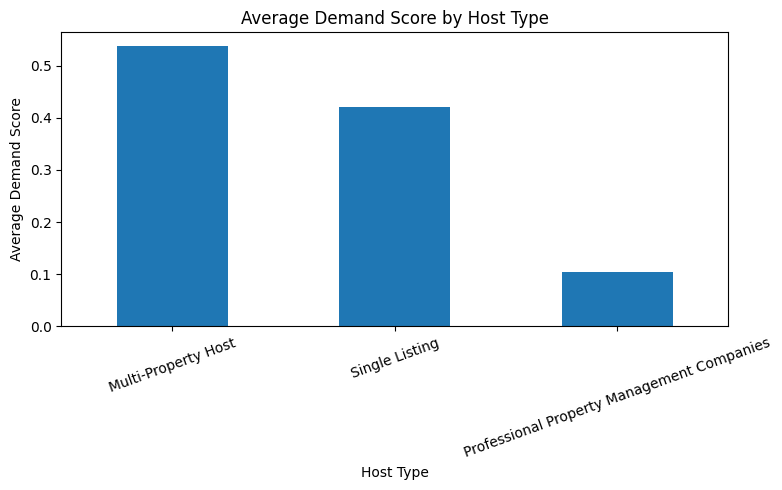

In [329]:
host_demand = (
    df.groupby('Host Type')['demand_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
host_demand.plot(kind='bar')

plt.title('Average Demand Score by Host Type')
plt.xlabel('Host Type')
plt.ylabel('Average Demand Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

1. Verification Status Doesn't Matter Much
Verified and unverified hosts have nearly identical:
Ratings
Reviews/month
Availability
Portfolio sizes
2. Price Isn't A Success Driver
All host categories charge roughly the same prices.
Differences are negligible.
3. Host Portfolio Size Matters
Single Listing Hosts
Multi-Property Hosts
Professional Property Companies
behave differently.

4. Multi-Property Hosts Perform Best
Highest average reviews
Highest reviews/month
Strong ratings
5. Professional Companies Have Highest Availability
More inventory available
But lower engagement per listing
6. Property Mix Explains Part Of The Story
Multi-property hosts own many private rooms
Professionals own a more balanced portfolio
Even after controlling for room type, Multi-property hosts still outperform

### KPI 4: Demand & Occupancy Analysis

#### Business Question
Which listings appear to have the strongest demand?

#### Metrics
- Availability 365
- Reviews Per Month
- Number of Reviews
- Price

#### Demand Indicators

High Demand:
- Low Availability
- High Reviews Per Month

Low Demand:
- High Availability
- Low Reviews Per Month

#### Expected Outcome
Identify characteristics associated with highly demanded listings.

In [312]:
df['demand_score'] = (
    np.log1p(df['number of reviews'])
    * df['reviews per month'].fillna(0)
) / (df['availability 365'] + 1)

In [ ]:
df.groupby('room type')['demand_score'].mean()
#Hotel rooms exhibit the highest demand score by a significant margin, suggesting strong booking frequency relative to availability. However, hotel rooms represent less than 0.2% of listings and therefore do not drive the overall Airbnb market.

room type
Entire home/apt    0.356914
Hotel room         1.542671
Private room       0.474976
Shared room        0.422356
Name: demand_score, dtype: float64

In [ ]:
df.groupby('neighbourhood group')['demand_score'].mean()
#the most popular areas are Manhattan , Brooklyn and Queens 

neighbourhood group
Bronx            0.318459
Brooklyn         0.428800
Manhattan        0.400456
Queens           0.428078
Staten Island    0.377508
Name: demand_score, dtype: float64

In [315]:
pd.cut(df['price'], bins=[0,200,400,600,800,1200])

0         (800, 1200]
1            (0, 200]
2          (600, 800]
3          (200, 400]
4          (200, 400]
             ...     
100872     (600, 800]
100873    (800, 1200]
100874     (200, 400]
100875    (800, 1200]
100876    (800, 1200]
Name: price, Length: 100877, dtype: category
Categories (5, interval[int64, right]): [(0, 200] < (200, 400] < (400, 600] < (600, 800] < (800, 1200]]

In [ ]:
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[0,200,400,600,800,1200]
)

price_demand = (
    df.groupby('price_bucket')['demand_score']
    .mean()
    .sort_index()
)

print(price_demand)
#based on the price based  we can see that there is a better demand for cheap properties and expensive proprties (prefer either or true in between )

price_bucket
(0, 200]       0.440725
(200, 400]     0.386687
(400, 600]     0.431897
(600, 800]     0.393935
(800, 1200]    0.416418
Name: demand_score, dtype: float64


/var/folders/39/pt6v5j6d1sl0_v9jrw837wjr0000gp/T/ipykernel_24241/606018216.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bucket')['demand_score']


In [ ]:
df.groupby('price_bucket').agg(
    listings=('id','count'),
    avg_demand=('demand_score','mean')
)
#there's also a lot more properties in the higher price range

/var/folders/39/pt6v5j6d1sl0_v9jrw837wjr0000gp/T/ipykernel_24241/640853836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bucket').agg(


,listings,avg_demand
price_bucket,,
"(0, 200]",13057,0.440725
"(200, 400]",17282,0.386687
"(400, 600]",17819,0.431897
"(600, 800]",17833,0.393935
"(800, 1200]",34886,0.416418


In [ ]:
#as seen in previous KPI the market field is dominated by multi property host types . 
df.groupby('Host Type')['demand_score'].mean()

Host Type
Multi-Property Host                           0.536992
Professional Property Management Companies    0.105013
Single Listing                                0.421089
Name: demand_score, dtype: float64

In [320]:
kpi4_summary = {
    "Highest Demand Room Type": df.groupby('room type')['demand_score'].mean().idxmax(),
    "Highest Demand Borough": df.groupby('neighbourhood group')['demand_score'].mean().idxmax(),
    "Highest Demand Host Type": df.groupby('Host Type')['demand_score'].mean().idxmax(),
    "Highest Demand Price Bucket": price_demand.idxmax()
}

print(kpi4_summary)

{'Highest Demand Room Type': 'Hotel room', 'Highest Demand Borough': 'Brooklyn', 'Highest Demand Host Type': 'Multi-Property Host', 'Highest Demand Price Bucket': Interval(0, 200, closed='right')}


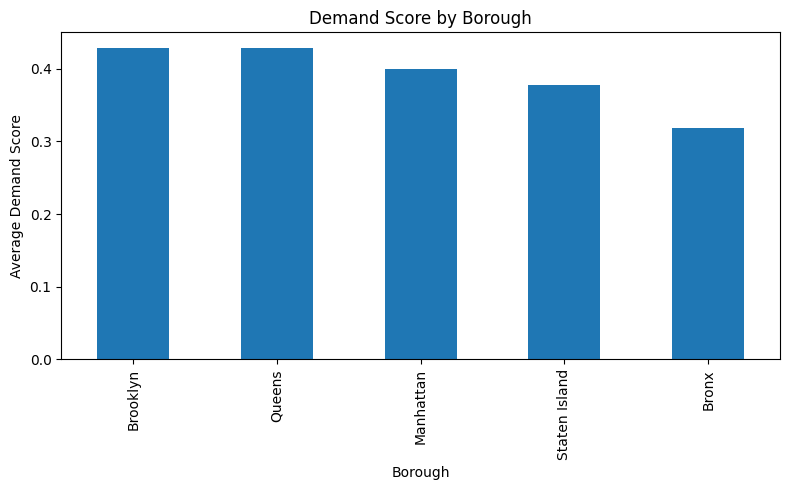

In [331]:
borough_demand = (
    df.groupby('neighbourhood group')['demand_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
borough_demand.plot(kind='bar')

plt.title('Demand Score by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Demand Score')
plt.tight_layout()
plt.show()

/var/folders/39/pt6v5j6d1sl0_v9jrw837wjr0000gp/T/ipykernel_24241/2889835467.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bucket')['demand_score']


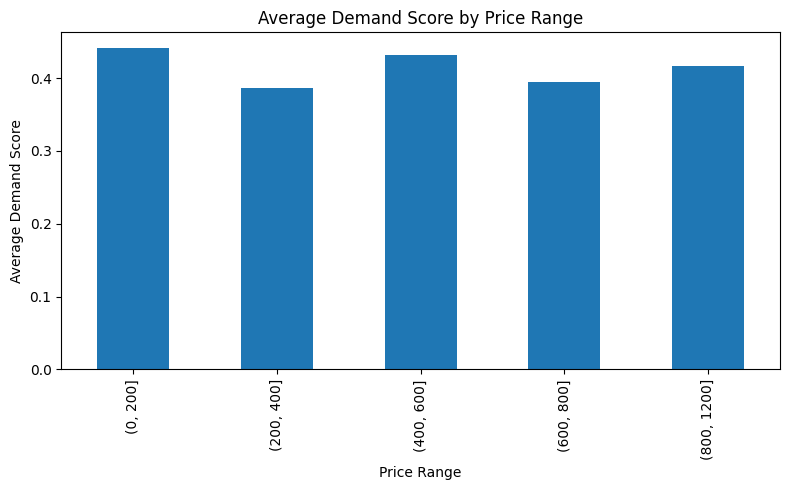

In [330]:
price_demand = (
    df.groupby('price_bucket')['demand_score']
    .mean()
)

plt.figure(figsize=(8,5))
price_demand.plot(kind='bar')

plt.title('Average Demand Score by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Demand Score')
plt.tight_layout()
plt.show()

Demand does not decline uniformly with increasing prices. Budget listings (0-200) achieve the highest average demand score, while premium listings (800-1200) maintain relatively strong demand despite commanding higher prices. Mid-range properties in the 200-400 and 600-800 brackets experience comparatively weaker demand, suggesting a possible preference among customers for either value-oriented or premium accommodation options.

### KPI 5: Customer Satisfaction Analysis

#### Business Question
What factors contribute to higher review ratings?

#### Metrics
- Review Rate Number
- Price
- Room Type
- Host Verification
- Availability
- Instant Bookable Status

#### Expected Outcome
Identify factors that drive positive guest experiences and better ratings.

In [ ]:
#factors contributing to a higher customer satisfaction rate 
customer_satisfaction_price = df.groupby('review rate number').agg(
    avg_price = ('price' , 'mean')
)
print(customer_satisfaction_price)
#cannot extract suitbable information from this split up 

                     avg_price
review rate number            
1.0                 627.774222
2.0                 626.959046
3.0                 625.733056
4.0                 626.909052
5.0                 621.684030


In [ ]:
#checking based on room type 
customer_satisfaction_room_type = df.groupby(['review rate number', 'room type']).agg(
    avg_price = ('price' , 'mean') , 
    median_price = ('price' , 'median') , 
    listings = ('id', 'count')
)
print(customer_satisfaction_room_type)
#the distribution of hotels is way too less , in a market dominated by entirehomes/apts and private rooms , not really any conclusive pattern taht can be seen so no dependency here

                                     avg_price  median_price  listings
review rate number room type                                          
1.0                Entire home/apt  627.165803    630.000000      4827
                   Private room     627.283812    630.347545      4080
                   Shared room      658.829007    698.000000       159
2.0                Entire home/apt  631.572542    635.000000     11965
                   Hotel room       741.666667    743.000000        27
                   Private room     621.855916    620.000000     10324
                   Shared room      615.457280    628.500000       488
3.0                Entire home/apt  620.957037    620.000000     11983
                   Hotel room       599.193548    554.000000        31
                   Private room     630.189043    632.000000     10386
                   Shared room      647.218229    647.000000       548
4.0                Entire home/apt  626.729271    627.000000     11919
      

In [ ]:
#host verification 
customer_satisfaction_host_verified = df.groupby(['review rate number' , 'host_identity_verified']).agg(
    median_price = ('price' , 'median') , 
    listings = ('id' , 'count')
)
print(customer_satisfaction_host_verified)
#everything seems to uniformly distributed

                                           median_price  listings
review rate number host_identity_verified                        
1.0                unconfirmed               637.000000      4622
                   verified                  626.000000      4444
2.0                unconfirmed               633.000000     11433
                   verified                  624.943236     11371
3.0                unconfirmed               626.000000     11555
                   verified                  628.000000     11393
4.0                unconfirmed               619.000000     11525
                   verified                  628.000000     11455
5.0                unconfirmed               623.000000     11464
                   verified                  614.000000     11582


In [ ]:
customer_satisfaction_availability = df.groupby('review rate number').agg(
    median_price = ('price' , 'median') , 
    availability = ('availability 365' , 'mean')
)
print(customer_satisfaction_availability)

#the ratings are spread unifromly across avaliability 

                    median_price  availability
review rate number                            
1.0                   631.000000    147.424553
2.0                   627.331105    141.834590
3.0                   627.000000    140.056911
4.0                   625.000000    140.012968
5.0                   619.000000    142.036796


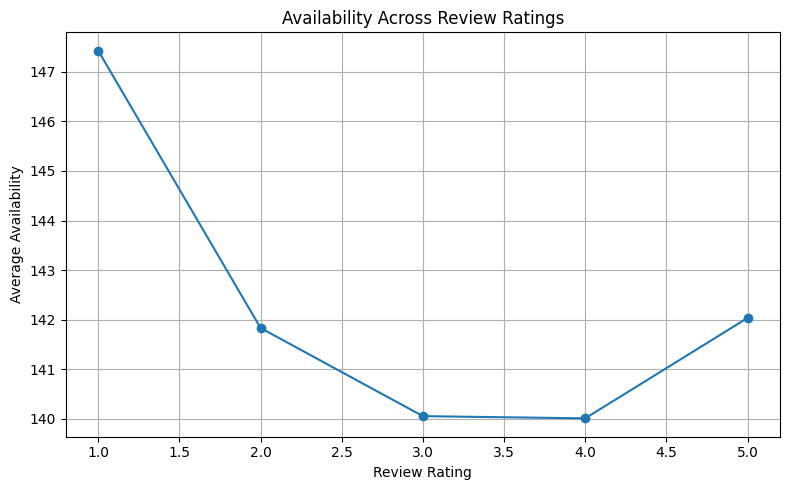

In [333]:
availability_rating = (
    df.groupby('review rate number')['availability 365']
    .mean()
)

plt.figure(figsize=(8,5))
availability_rating.plot(marker='o')

plt.title('Availability Across Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Average Availability')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
customer_satisfaction_instant_bookable = df.groupby(['review rate number','instant_bookable' ] ).agg(
    median_price = ('price' , 'median') , 
    listings = ('id' , 'count')
)
print(customer_satisfaction_instant_bookable)
#evenly distributed here too , with not soo mcuh price discrepancy can't get a pattern 

                                     median_price  listings
review rate number instant_bookable                        
1.0                False                    643.0      4563
                   True                     617.0      4490
2.0                False                    630.0     11464
                   True                     625.0     11331
3.0                False                    627.0     11562
                   True                     628.0     11362
4.0                False                    626.0     11554
                   True                     623.0     11411
5.0                False                    615.0     11473
                   True                     621.0     11554


It can be seen that there is no dependence of customer satisfaction on any of the following parameters in the system 

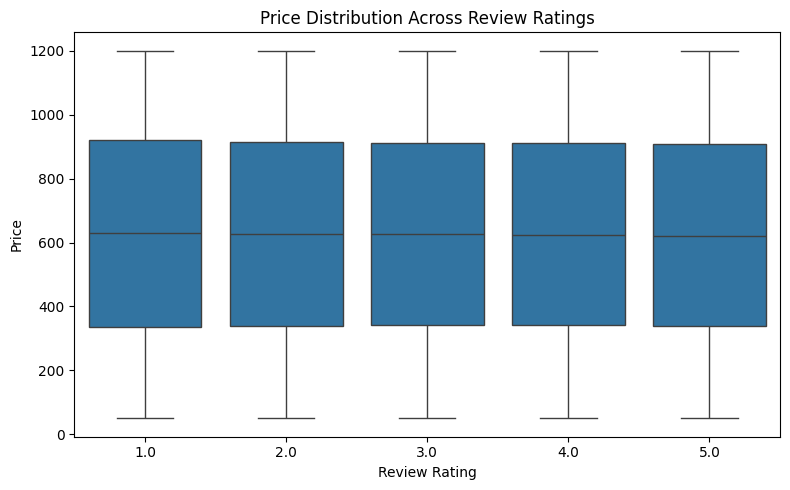

In [332]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='review rate number',
    y='price'
)

plt.title('Price Distribution Across Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

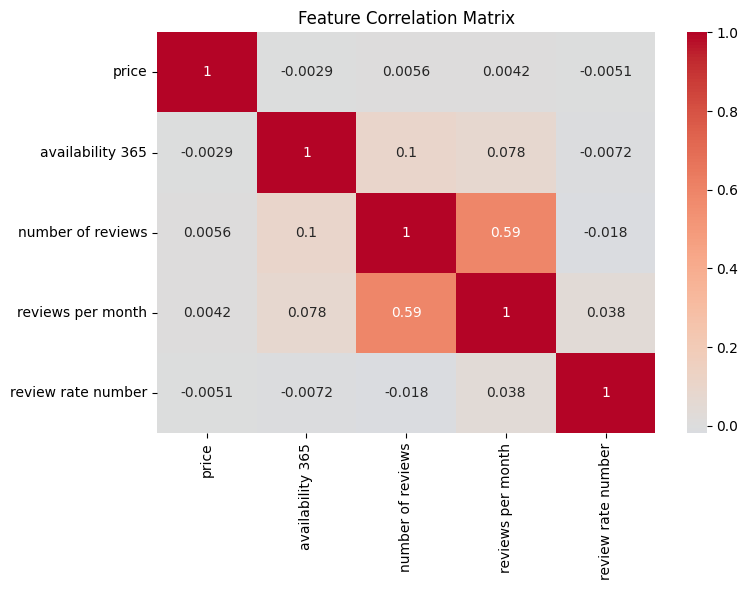

In [334]:
correlation_cols = [
    'price',
    'availability 365',
    'number of reviews',
    'reviews per month',
    'review rate number'
]

corr = df[correlation_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### KPI 6: Price Recommendation Model

#### Business Question
Can listing prices be estimated using listing characteristics?

#### Target Variable
- Price

#### Features
- Neighborhood Group
- Neighborhood
- Room Type
- Host Verification
- Instant Bookable
- Availability
- Review Rate Number
- Reviews Per Month
- Construction Year
- Host Listings Count

#### Model Type
- Linear Regression
- Random Forest Regressor
- XGBoost (Optional)

#### Evaluation Metrics
- MAE
- RMSE
- R² Score
### Expected Outcome
Develop a pricing recommendation system capable of estimating listing prices from listing attributes.

In [339]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 42.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 6.9 MB/s  0:00:03 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [340]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [341]:
target = 'review rate number'

features = [
    'price',
    'service fee',
    'availability 365',
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'calculated host listings count',
    'room type',
    'neighbourhood group',
    'host_identity_verified',
    'instant_bookable'
]

X = df[features]
y = df[target]

In [342]:
numeric_features = [
    'price',
    'service fee',
    'availability 365',
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'calculated host listings count'
]

categorical_features = [
    'room type',
    'neighbourhood group',
    'host_identity_verified',
    'instant_bookable'
]

In [343]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [ ]:
df_ml = df.dropna(subset=['review rate number'])

X = df_ml[features]
y = df_ml['review rate number']

In [350]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [351]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2:", r2_score(y_test, predictions))

MAE: 0.820308414433749
R2: 0.35661976842275644


In [353]:
feature_names = (
    numeric_features +
    list(
        model.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(categorical_features)
    )
)

importances = (
    model.named_steps['regressor']
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
)

print(importance_df.head(15))

                               feature  importance
0                                price    0.182330
2                     availability 365    0.176283
5                    reviews per month    0.146838
1                          service fee    0.117759
4                    number of reviews    0.102074
3                       minimum nights    0.087256
6       calculated host listings count    0.051250
12        neighbourhood group_Brooklyn    0.017949
13       neighbourhood group_Manhattan    0.017947
9               room type_Private room    0.015367
7            room type_Entire home/apt    0.015048
14          neighbourhood group_Queens    0.013224
17     host_identity_verified_verified    0.011327
16  host_identity_verified_unconfirmed    0.011302
19               instant_bookable_True    0.011177
